In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain
# from deep_lss.utils import configuration

from msi.utils import diagnostics

In [3]:
# samples_file = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_7/likelihood_flow/mcmc_samples.h5"
# samples_file = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test/likelihood_flow/mcmc_samples.h5"
# samples_file = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v2/likelihood_flow/mcmc_samples.h5"
samples_file = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v3/likelihood_flow/mcmc_samples.h5"
# samples_file = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/400000_steps_likelihood_sigmoid_test_v4/likelihood_flow/mcmc_samples.h5"


with h5py.File(samples_file, "r") as f:
    x_true = f["x_true"][:]
    theta_true = f["theta_true"][:]
    log_prob_true = f["log_prob_true"][:]
    
    theta_sample = f["theta_sample"][:]
    log_prob_sample = f["log_prob_sample"][:]

print(x_true.shape)
print(theta_true.shape)
print(log_prob_true.shape)
print(theta_sample.shape)
print(log_prob_sample.shape)

(1000, 20)
(1000, 10)
(1000,)
(10000, 1000, 10)
(10000, 1000)


In [4]:
# because rerun_missing is currently broken
mask = x_true != 0
mask = np.any(mask, axis=1)

x_true = x_true[mask]
theta_true = theta_true[mask]
log_prob_true = log_prob_true[mask]
theta_sample = theta_sample[:,mask]
log_prob_sample = log_prob_sample[:,mask]

print(np.sum(mask))

991


In [5]:
# i_sim = 0

# tri = TriangleChain()
# tri.scatter(
#     theta_true[i_sim][np.newaxis], 
#     scatter_kwargs={"s": 500, "marker": "*"},
#     color="k",
# )
# tri.scatter(
#     # theta_sample[:,i_sim],
#     theta_sample[:100,i_sim],
#     scatter_kwargs={"s": 10, "marker": "o"},
#     color="tab:blue",
# );

100%|████████████████████████████|   | 991/991 [00:00<00:00, 1570.73it/s]     EECP: looping through cosmos


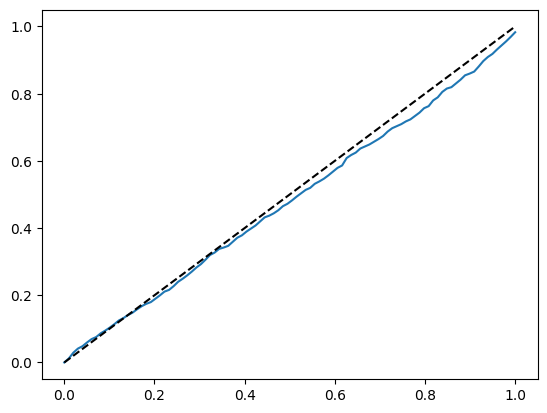

In [6]:
hpd_alpha, hpd_ecp = diagnostics.posterior_hpd_check(
    log_prob_true,
    log_prob_sample,
    n_alpha=100,
)

fig, ax = plt.subplots()
ax.plot(hpd_alpha, hpd_ecp)
ax.plot(hpd_alpha, hpd_alpha, color="k", linestyle="--")

In [ ]:
tarp_alpha, tarp_ecp, tarp_ecp_std = diagnostics.posterior_tarp_check(
    theta_true,
    theta_sample,
    n_bootstrap=100,
    n_alpha=20,
)

fig, ax = plt.subplots()
ax.plot(tarp_alpha, tarp_ecp)
n_sigma = 2
ax.fill_between(
    tarp_alpha,
    tarp_ecp - n_sigma * tarp_ecp_std,
    tarp_ecp + n_sigma * tarp_ecp_std,
    label=str(n_sigma) + r"$\sigma$",
    alpha=0.3,
)
ax.plot(tarp_alpha, tarp_alpha, color="k", linestyle="--")

 25%|██▌       | 25/100 [00:15<00:46,  1.63it/s]

# trash